# Job Market Intelligence – Exploratory Data Analysis

This notebook explores the cleaned No Fluff Jobs dataset to identify patterns in job demand, experience levels, workplace models, contract types, salaries, and technologies.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "nofluff_it_jobs_clean.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (2856, 30)


## Analysis plan

The exploratory analysis focuses on four main questions:

1. What experience levels are most in demand?
2. What workplace models and contract types are most common?
3. How do salaries differ across experience levels and job categories?
4. Which technologies and skills are most frequently required?

## 1. Dataset overview

This section provides a high-level overview of the dataset, including the number
of job offers, companies, categories, salary availability, and data collection period.


In [2]:
# Convert scraping date to datetime
df["scraped_at"] = pd.to_datetime(
    df["scraped_at"],
    errors="coerce"
)

overview = pd.Series({
    "Job offers": len(df),
    "Unique companies": df["company"].nunique(),
    "Unique job titles": df["title"].nunique(),
    "Unique categories": df["category"].nunique(),
    "Offers with salary": df["salary_min"].notna().sum(),
    "Salary analysis eligible": df["salary_analysis_eligible"].sum(),
})

overview

Job offers                  2856
Unique companies             358
Unique job titles           2318
Unique categories             53
Offers with salary          2622
Salary analysis eligible    1470
dtype: int64

In [3]:
salary_available_pct = (
    df["salary_min"].notna().mean() * 100
)

salary_eligible_pct = (
    df["salary_analysis_eligible"].mean() * 100
)

print(
    f"Offers with salary: "
    f"{salary_available_pct:.1f}%"
)

print(
    f"Offers eligible for salary analysis: "
    f"{salary_eligible_pct:.1f}%"
)

print()
print(
    "Data collection period:",
    df["scraped_at"].min().date(),
    "to",
    df["scraped_at"].max().date()
)

Offers with salary: 91.8%
Offers eligible for salary analysis: 51.5%

Data collection period: 2026-08-23 to 2026-08-23


In [4]:
df[
    [
        "title",
        "company",
        "experience",
        "workplace",
        "salary_min",
        "salary_max"
    ]
].head()

,title,company,experience,workplace,salary_min,salary_max
0,Administrator IT,iteo S.A.,Mid,NaN,10000.0,13000.0
1,Administrator/-ka Aplikacji Biznesowych - Depa...,T-Mobile Polska,Mid,Hybrid,11928.0,15960.0
2,Administrator/ka IT,IMA POLSKA SPÓŁKA AKCYJNA,Mid,Onsite,9900.0,13900.0
3,ADMINISTRATOR SAP BASIS (k/m),MODIVO PLATFORM,Mid,Onsite,38000.0,45000.0
4,Administrator Systemów Linux/BSD (z elementami...,Fudo Security,Mid,Hybrid,72.0,96.0


### Key observations

- The dataset contains 3,309 unique job offers from 386 companies.
- There are 2,646 unique job titles, which indicates high diversity in job naming.
- Salary information is available for 70.8% of offers.
- 70.1% of all offers meet the criteria used for salary analysis.
- The data was collected between August 13 and August 15, 2026.
- The dataset contains 50 unique category values; some of them may represent combinations of multiple job categories rather than single categories.

## 2. Experience level

This section examines the distribution of job offers across different experience levels.

In [5]:
experience_counts = (
    df["experience"]
    .value_counts(dropna=False)
    .to_frame("job_offers")
)

experience_counts

,job_offers
experience,
Senior,1485
Mid,1040
Junior,121
Expert,118
NaN,92


In [6]:
experience_summary = (
    df["experience"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("experience")
    .reset_index(name="job_offers")
)

experience_summary["percentage"] = (
    experience_summary["job_offers"]
    / len(df)
    * 100
).round(1)

experience_summary

,experience,job_offers,percentage
0,Senior,1485,52.0
1,Mid,1040,36.4
2,Junior,121,4.2
3,Expert,118,4.1
4,Missing,92,3.2


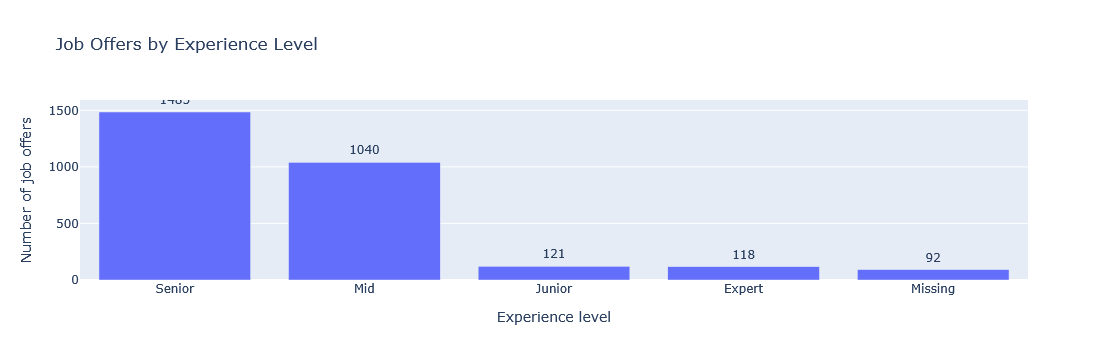

In [7]:
import plotly.express as px

experience_order = [
    "Senior",
    "Mid",
    "Junior",
    "Expert",
    "Missing"
]

fig = px.bar(
    experience_summary,
    x="experience",
    y="job_offers",
    text="job_offers",
    category_orders={
        "experience": experience_order
    },
    title="Job Offers by Experience Level",
    labels={
        "experience": "Experience level",
        "job_offers": "Number of job offers"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

### Key observation

Senior and Mid-level positions dominate the dataset, accounting for approximately
90% of all job offers. Senior roles alone represent more than half of the analysed
job market, while Junior positions account for only around 5.5%.

This suggests that the analysed IT job market is strongly oriented toward
experienced professionals.

In [8]:
df['experience_years_min'].describe()

count    1437.000000
mean        4.768963
std         1.959779
min         1.000000
25%         3.000000
50%         5.000000
75%         5.000000
max        15.000000
Name: experience_years_min, dtype: float64

In [9]:
df.groupby('experience')['experience_years_min'].describe()

,count,mean,std,min,25%,50%,75%,max
experience,,,,,,,,
Expert,61.0,6.672131,2.378524,3.0,5.0,7.0,8.0,15.0
Junior,39.0,3.128205,2.117341,1.0,2.0,2.0,5.0,10.0
Mid,514.0,3.747082,1.747803,1.0,3.0,3.0,5.0,10.0
Senior,822.0,5.347932,1.671022,1.0,5.0,5.0,6.0,15.0


In [10]:
liczba = ((df['experience'] == 'Junior') & (df['experience_years_min'] > 5)).sum()
print(liczba)
liczba = ((df['experience'] == 'Mid') & (df['experience_years_min'] > 10)).sum()
print(liczba)



3
0


In [11]:
junior_anomalies = df[
    (df["experience"] == "Junior")
    & (df["experience_years_min"] > 5)
][
    [
        "title",
        "company",
        "experience",
        "experience_years_min",
        "requirements"
    ]
]

junior_anomalies

,title,company,experience,experience_years_min,requirements
673,Frontend Developer,Mindbox Sp. z o.o.,Junior,7.0,Oryginalny tekst. Pokaż tłumaczenie 7+ years o...
1303,OT Network Support Specialist,Mindbox Sp. z o.o.,Junior,8.0,Oryginalny tekst. Pokaż tłumaczenie 8+ years o...
2451,ServiceNow Technical Lead - AI Solutions Delivery,Belvedere Recruitment,Junior,10.0,Oryginalny tekst. Pokaż tłumaczenie 10+ years ...


In [12]:
experience_years = (
    df.groupby("experience")["experience_years_min"]
    .agg(
        job_offers="count",
        median_years="median",
        mean_years="mean"
    )
    .round(1)
)

experience_years

,job_offers,median_years,mean_years
experience,,,
Expert,61,7.0,6.7
Junior,39,2.0,3.1
Mid,514,3.0,3.7
Senior,822,5.0,5.3


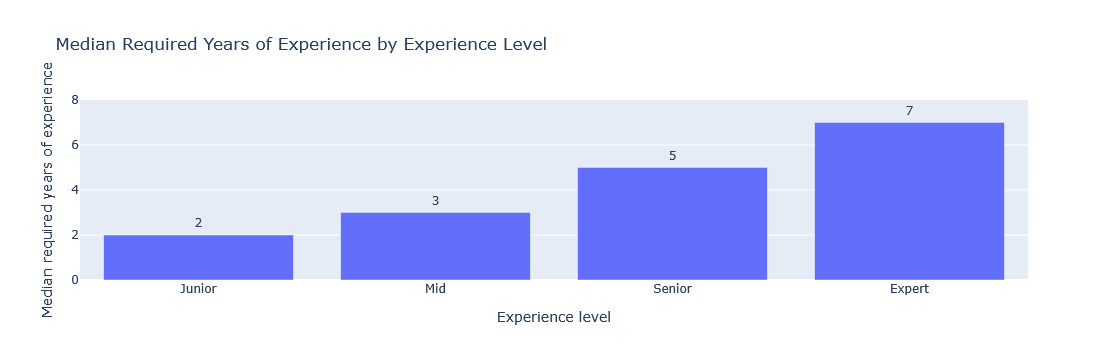

In [13]:
import plotly.express as px

experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

median_experience = (
    df.groupby("experience")["experience_years_min"]
    .median()
    .reindex(experience_order)
    .reset_index()
)

fig = px.bar(
    median_experience,
    x="experience",
    y="experience_years_min",
    text="experience_years_min",
    title="Median Required Years of Experience by Experience Level",
    labels={
        "experience": "Experience level",
        "experience_years_min": "Median required years"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False,
    yaxis_title="Median required years of experience",
    xaxis_title="Experience level"
)

fig.update_yaxes(
    range=[0, 8]
)

fig.show()

In [14]:
df['workplace'].value_counts().sum()

np.int64(2533)

In [15]:
df.groupby('workplace')['job_id'].count() / df['job_id'].count() * 100

workplace
Hybrid    53.641457
Onsite     0.350140
Remote    34.698880
Name: job_id, dtype: float64

In [16]:
workplace_summary = (
    df["workplace"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("workplace")
    .reset_index(name="job_offers")
)

workplace_summary["percentage"] = (
    workplace_summary["job_offers"]
    / len(df)
    * 100
).round(1)

workplace_summary

,workplace,job_offers,percentage
0,Hybrid,1532,53.6
1,Remote,991,34.7
2,Missing,323,11.3
3,Onsite,10,0.4


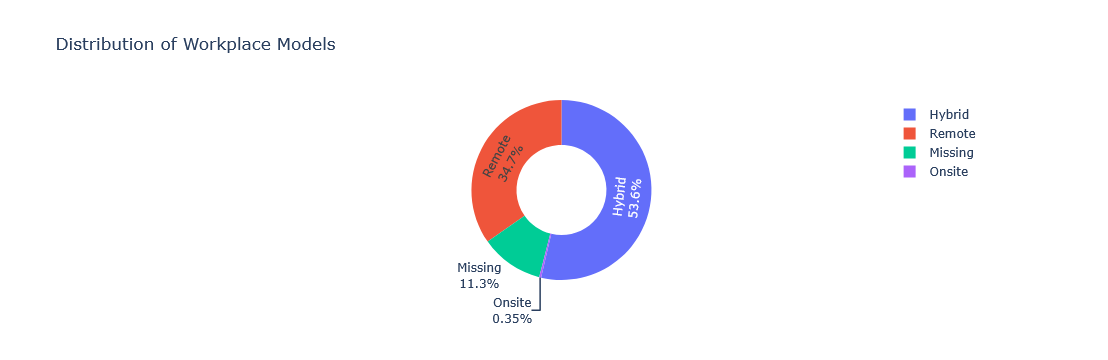

In [17]:
fig = px.pie(
    workplace_summary,
    names="workplace",
    values="job_offers",
    hole=0.5,
    title="Distribution of Workplace Models"
)

fig.update_traces(
    textinfo="percent+label"
)

fig.show()

In [18]:
workplace_experience = (
    pd.crosstab(
        df["experience"],
        df["workplace"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

workplace_experience

workplace,Hybrid,Missing,Onsite,Remote
experience,,,,
Expert,69.5,1.7,0.0,28.8
Junior,63.6,17.4,0.0,19.0
Mid,57.9,12.8,0.9,28.5
Senior,50.8,6.4,0.0,42.8


In [19]:
workplace_experience_plot = (
    workplace_experience
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="workplace",
        value_name="percentage"
    )
)

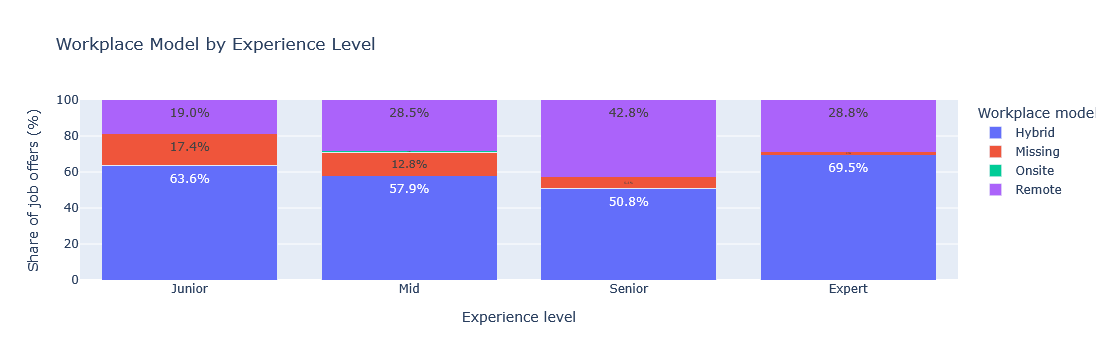

In [20]:
fig = px.bar(
    workplace_experience_plot,
    x="experience",
    y="percentage",
    color="workplace",
    text="percentage",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Workplace Model by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "workplace": "Workplace model"
    }
)

fig.update_layout(
    barmode="stack",
    yaxis_range=[0, 100]
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="inside"
)

fig.show()

## 4. Job categories

This section explores the distribution of job offers across different job categories.

Some offers contain multiple categories, so the initial analysis focuses on the raw category values before deciding whether they should be split into separate categories.

In [21]:
top_categories = (
    df["category"]
    .fillna("Missing")
    .value_counts()
    .head(20)
    .rename_axis("category")
    .reset_index(name="job_offers")
)

top_categories

,category,job_offers
0,Backend,252
1,Missing,218
2,Data,211
3,DevOps,208
4,Testing,175
5,"Java, Backend",171
6,ERP,169
7,Project Manager,159
8,Security,147
9,Architecture,126


In [22]:
categories_exploded = (
    df[["job_id", "category"]]
    .dropna(subset=["category"])
    .assign(
        category=lambda x:
        x["category"].str.split(",")
    )
    .explode("category")
)

categories_exploded["category"] = (
    categories_exploded["category"]
    .str.strip()
)

In [23]:
top_categories_exploded = (
    categories_exploded["category"]
    .value_counts()
    .head(20)
    .rename_axis("category")
    .reset_index(name="job_offers")
)

top_categories_exploded

,category,job_offers
0,Backend,536
1,Data,284
2,Java,267
3,Python,261
4,DevOps,248
5,Testing,227
6,Fullstack,204
7,ERP,170
8,AI,169
9,Project Manager,161


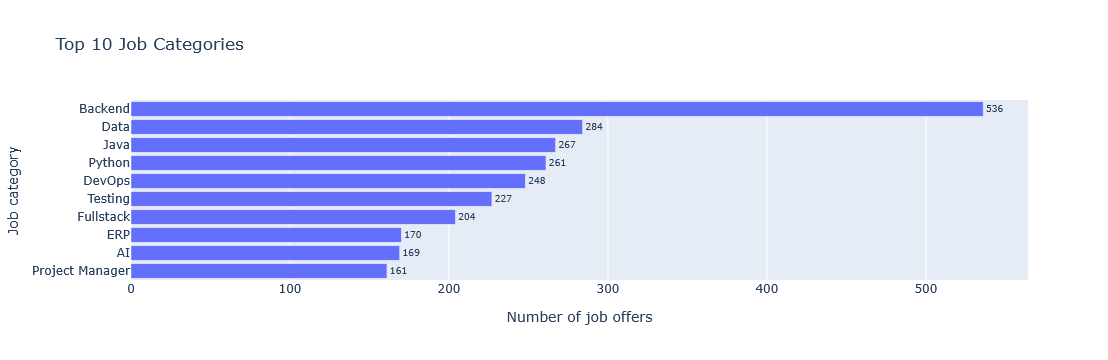

In [24]:
top_10_categories = (
    top_categories_exploded
    .head(10)
    .sort_values(
        "job_offers",
        ascending=True
    )
)

fig = px.bar(
    top_10_categories,
    x="job_offers",
    y="category",
    orientation="h",
    text="job_offers",
    title="Top 10 Job Categories",
    labels={
        "job_offers": "Number of job offers",
        "category": "Job category"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

In [25]:
top_10_category_names = (
    top_categories_exploded
    .head(10)["category"]
    .tolist()
)

category_experience_df = (
    categories_exploded
    .merge(
        df[
            [
                "job_id",
                "experience"
            ]
        ],
        on="job_id",
        how="left"
    )
)

category_experience_df = (
    category_experience_df[
        category_experience_df["category"]
        .isin(top_10_category_names)
    ]
    .dropna(subset=["experience"])
)

In [26]:
category_experience = (
    pd.crosstab(
        category_experience_df["category"],
        category_experience_df["experience"],
        normalize="index"
    )
    * 100
).round(1)

category_experience = (
    category_experience
    .reindex(
        index=top_10_category_names,
        columns=[
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ],
        fill_value=0
    )
)

category_experience

experience,Junior,Mid,Senior,Expert
category,,,,
Backend,4.4,29.9,62.7,2.9
Data,4.0,34.7,54.2,7.2
Java,4.9,26.4,66.8,1.9
Python,2.7,27.6,65.8,3.9
DevOps,2.9,34.6,60.1,2.5
Testing,7.3,49.3,41.6,1.8
Fullstack,1.0,33.3,62.6,3.0
ERP,2.4,43.0,49.7,4.8
AI,4.3,25.8,62.6,7.4


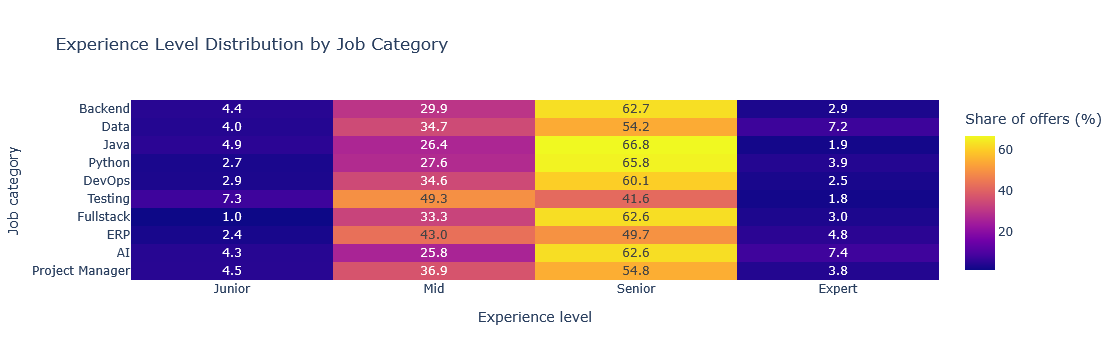

In [27]:
fig = px.imshow(
    category_experience,
    text_auto=".1f",
    aspect="auto",
    title="Experience Level Distribution by Job Category",
    labels={
        "x": "Experience level",
        "y": "Job category",
        "color": "Share of offers (%)"
    }
)

fig.show()

## 5. Contract types

This section examines the distribution of employment contract types across job offers.

The initial analysis uses the original contract values, including offers that provide multiple contract options. Missing contract information is also included to show the completeness of the data.

In [28]:
df['contract_type'].unique()

array(['B2B', nan, 'B2B, Umowa o pracę', 'Umowa o pracę',
       'B2B, Umowa zlecenie', 'Umowa zlecenie',
       'Umowa o pracę, Umowa zlecenie'], dtype=object)

In [29]:
contract_type_summary = (
    df["contract_type"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("contract_type")
    .reset_index(name="job_offers")
)

contract_type_summary["percentage"] = (
    contract_type_summary["job_offers"]
    / len(df)
    * 100
).round(1)

contract_type_summary

,contract_type,job_offers,percentage
0,B2B,1840,64.4
1,Missing,712,24.9
2,"B2B, Umowa o pracę",199,7.0
3,Umowa o pracę,101,3.5
4,Umowa zlecenie,2,0.1
5,"B2B, Umowa zlecenie",1,0.0
6,"Umowa o pracę, Umowa zlecenie",1,0.0


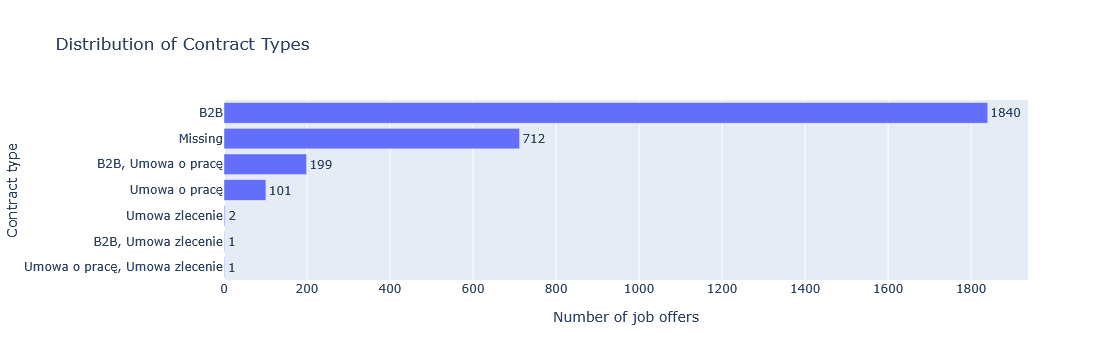

In [30]:
contract_type_plot = (
    contract_type_summary
    .sort_values(
        "job_offers",
        ascending=True
    )
)

fig = px.bar(
    contract_type_plot,
    x="job_offers",
    y="contract_type",
    orientation="h",
    text="job_offers",
    title="Distribution of Contract Types",
    labels={
        "job_offers": "Number of job offers",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

### Key observation

B2B is the dominant contract type in the dataset, while traditional employment contracts appear much less frequently.

A substantial share of offers does not provide contract information, so missing values should be considered when interpreting the distribution.

In [31]:
abc = df.groupby('contract_type')['experience'].count()

In [32]:
abc

contract_type
B2B                              1838
B2B, Umowa o pracę                199
B2B, Umowa zlecenie                 1
Umowa o pracę                     101
Umowa o pracę, Umowa zlecenie       1
Umowa zlecenie                      2
Name: experience, dtype: int64

In [33]:
experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

contract_experience = (
    pd.crosstab(
        df["experience"],
        df["contract_type"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

contract_experience = (
    contract_experience
    .reindex(experience_order)
)

contract_experience

contract_type,B2B,"B2B, Umowa o pracę","B2B, Umowa zlecenie",Missing,Umowa o pracę,"Umowa o pracę, Umowa zlecenie",Umowa zlecenie
experience,,,,,,,
Junior,42.1,8.3,0.0,38.8,8.3,0.8,1.7
Mid,67.2,8.8,0.1,19.8,4.1,0.0,0.0
Senior,69.1,5.9,0.0,22.0,3.0,0.0,0.0
Expert,52.5,8.5,0.0,35.6,3.4,0.0,0.0


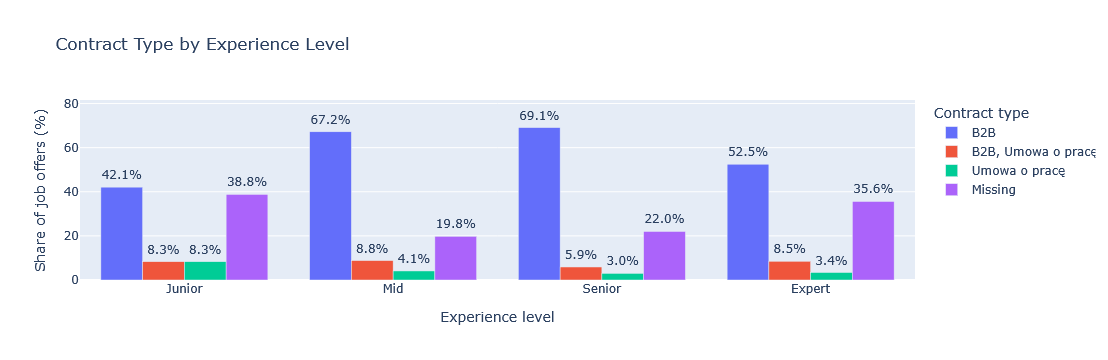

In [34]:
main_contract_types = [
    "B2B",
    "B2B, Umowa o pracę",
    "Umowa o pracę",
    "Missing"
]

contract_experience_plot = (
    contract_experience[
        main_contract_types
    ]
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="contract_type",
        value_name="percentage"
    )
)

fig = px.bar(
    contract_experience_plot,
    x="experience",
    y="percentage",
    color="contract_type",
    barmode="group",
    text="percentage",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Contract Type by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.show()

## 6. Skills Analysis

This section identifies the technologies most frequently mentioned in job requirements. It also compares required and optional skills across experience levels and job categories.

In [35]:
skills_completeness = pd.Series({
    "Job offers": len(df),
    "Required skills available": df["required_skills"].notna().sum(),
    "Nice-to-have skills available": df["nice_to_have"].notna().sum(),
    "Required skills available (%)": (
        df["required_skills"].notna().mean() * 100
    ),
    "Nice-to-have skills available (%)": (
        df["nice_to_have"].notna().mean() * 100
    ),
}).round(1)

skills_completeness

Job offers                           2856.0
Required skills available            2761.0
Nice-to-have skills available        1791.0
Required skills available (%)          96.7
Nice-to-have skills available (%)      62.7
dtype: float64

In [36]:
df[
    ["title", "category", "required_skills", "nice_to_have"]
].dropna(subset=["required_skills"]).head(10)

,title,category,required_skills,nice_to_have
0,Administrator IT,NaN,Windows Linux macOS Jira CA TCP DHCP VPN SSO M...,JumpCloud Azure Apache Nginx AI
1,Administrator/-ka Aplikacji Biznesowych - Depa...,Support,Windows Linux SQL Polski,NaN
2,Administrator/ka IT,NaN,Windows Server Office 365 Active Directory Pow...,Hyper-V TCP/IP protocols VLAN VPN Microsoft De...
3,ADMINISTRATOR SAP BASIS (k/m),ERP,SAP Basis SAP Cloud HANA Linux HA ALM Polski,NaN
4,Administrator Systemów Linux/BSD (z elementami...,NaN,Linux Unix/BSD Networking Polski (Biegły) Angi...,Automation Infrastructure as Code IaC Virtuali...
5,Administrator Systemów Linux,NaN,Linux RHEL CentOS TCP IP Postfix Dovecot Tomca...,PostgreSQL MySQL Citrix Systems Samba OpenLDAP...
6,Administrator Windows (transformacja),Backend,Windows Server AD GPO DNS DHCP Polski,PowerShell Python Bash Ansible Git Prometheus ...
7,Adobe Analytics Specialist - IT Contracting,Data,Adobe Google Analytics Tableau Power BI,Polski
8,Agentic AI Technical Consultant | Poland,AI,AI Degree Data engineering Python System integ...,Salesforce SAP dbt Airflow Spark Databricks Ka...
9,Agentic AI Technical Senior Consultant | Poland,AI,AI Degree Data engineering Python Microservice...,dbt Airflow AWS Glue Spark Databricks Kafka Fl...


In [37]:
skill_patterns = {
    "Python": r"\bpython\b",
    "SQL": r"\bsql\b",
    "Excel": r"\bexcel\b",
    "Power BI": r"\bpower\s*bi\b|\bpowerbi\b",
    "Tableau": r"\btableau\b",
    "R": r"(?<![a-z])r(?![a-z])",
    "Java": r"\bjava\b(?!script)",
    "JavaScript": r"\bjavascript\b|\bjs\b",
    "TypeScript": r"\btypescript\b|\bts\b",
    "React": r"\breact(?:\.js)?\b",
    "Angular": r"\bangular\b",
    "Node.js": r"\bnode(?:\.js|js)?\b",
    "C#": r"\bc\s*#|csharp",
    ".NET": r"\.net\b|\bdotnet\b",
    "C++": r"\bc\+\+\b",
    "PHP": r"\bphp\b",
    "Scala": r"\bscala\b",
    "Go": r"\bgolang\b|\bgo\b",
    "AWS": r"\baws\b|amazon web services",
    "Azure": r"\bazure\b",
    "GCP": r"\bgcp\b|google cloud platform",
    "Docker": r"\bdocker\b",
    "Kubernetes": r"\bkubernetes\b|\bk8s\b",
    "Git": r"\bgit\b",
    "Linux": r"\blinux\b",
    "Spark": r"\b(?:apache\s+)?spark\b|\bpyspark\b",
    "Kafka": r"\b(?:apache\s+)?kafka\b",
    "Airflow": r"\b(?:apache\s+)?airflow\b",
    "Databricks": r"\bdatabricks\b",
    "Snowflake": r"\bsnowflake\b",
    "dbt": r"\bdbt\b",
    "Pandas": r"\bpandas\b",
    "NumPy": r"\bnumpy\b",
    "TensorFlow": r"\btensorflow\b",
    "PyTorch": r"\bpytorch\b",
    "Machine Learning": r"\bmachine learning\b|\bml\b",
    "GitHub": r"\bgithub\b",
    "Jira": r"\bjira\b",
    "Selenium": r"\bselenium\b",
}

In [38]:
import re

def extract_skills(text, patterns):
    if pd.isna(text):
        return []

    text = str(text).lower()

    return [
        skill
        for skill, pattern in patterns.items()
        if re.search(pattern, text, flags=re.IGNORECASE)
    ]

In [39]:
df["required_skills_list"] = (
    df["required_skills"]
    .apply(lambda text: extract_skills(text, skill_patterns))
)

df["nice_to_have_skills_list"] = (
    df["nice_to_have"]
    .apply(lambda text: extract_skills(text, skill_patterns))
)

In [40]:
df[
    [
        "title",
        "required_skills",
        "required_skills_list",
    ]
].head(10)

,title,required_skills,required_skills_list
0,Administrator IT,Windows Linux macOS Jira CA TCP DHCP VPN SSO M...,"[Linux, Jira]"
1,Administrator/-ka Aplikacji Biznesowych - Depa...,Windows Linux SQL Polski,"[SQL, Linux]"
2,Administrator/ka IT,Windows Server Office 365 Active Directory Pow...,[]
3,ADMINISTRATOR SAP BASIS (k/m),SAP Basis SAP Cloud HANA Linux HA ALM Polski,[Linux]
4,Administrator Systemów Linux/BSD (z elementami...,Linux Unix/BSD Networking Polski (Biegły) Angi...,[Linux]
5,Administrator Systemów Linux,Linux RHEL CentOS TCP IP Postfix Dovecot Tomca...,"[Python, Linux]"
6,Administrator Windows (transformacja),Windows Server AD GPO DNS DHCP Polski,[]
7,Adobe Analytics Specialist - IT Contracting,Adobe Google Analytics Tableau Power BI,"[Power BI, Tableau]"
8,Agentic AI Technical Consultant | Poland,AI Degree Data engineering Python System integ...,"[Python, AWS, Azure, GCP, Git]"
9,Agentic AI Technical Senior Consultant | Poland,AI Degree Data engineering Python Microservice...,"[Python, AWS, Azure, GCP]"


In [41]:
print(repr(df.loc[2, "required_skills"]))

'Windows Server Office 365 Active Directory PowerShell Intune Entra Angielski'


In [42]:
for value in df["required_skills"].dropna().sample(10, random_state=42):
    print(repr(value))
    print("---")

'Data engineering Java Python Scala SQL Apache Spark Databricks Apache Airflow Apache Kafka Amazon MSK Snowflake Amazon Redshift Angielski'
---
'Wykształcenie wyższe techniczne C++ C komunikacja techniczna Angielski (B2) Polski (B2)'
---
'Spark Cloud Data engineering SQL Python GCP Angielski'
---
'Windows Server Administration VMware Virtualization Networking TCP DNS Communication skills Security Angielski (Biegły)'
---
'DevOps Kubernetes CD Microservices architecture Linux Security Angielski'
---
'Linux DevOps Communication skills Angielski'
---
'Java Python Cloud AWS Azure GCP Cloud security Kubernetes Microservices Security Cybersecurity Angielski'
---
'Java REST API Microservices IBM MQ SQL PostgreSQL Sybase Communication skills Angielski'
---
'SQL Python GCP BigQuery Looker Studio Business analysis Dashboarding Angielski'
---
'Solution Architect Digital Complex business Integration patterns API Data flows Solution Design skills Logical architecture Integration minimum viable archi

In [43]:
df['company'].isna().sum()

np.int64(0)

In [44]:
df['company'].nunique()

358

In [45]:
print(f"{df['company_size'].notna().mean() * 100:.1f}%")

70.8%


In [46]:
import re

df["company_clean"] = (
    df["company"]
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\bsp z oo\b|\bsa\b|\bspółka z ograniczoną odpowiedzialnością\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

company_variants = (
    df.groupby("company_clean")["company"]
    .unique()
)

company_variants[
    company_variants.apply(len) > 1
]

company_clean
allegro                      [Allegro sp. z o.o., Allegro]
comscore via cc       [Comscore via CC, Comscore (via CC)]
dcg                                  [DCG, DCG sp. z o.o.]
finture            [Finture Sp. z o.o, Finture Sp. z o.o.]
iteamly                                 [iTeamly, Iteamly]
unityt group                [Unity-T Group, UNITY-T GROUP]
Name: company, dtype: object

In [47]:
company_mapping = {
    "Allegro sp. z o.o.": "Allegro",
    "DCG sp. z o.o.": "DCG",
    "Finture Sp. z o.o": "Finture",
    "Finture Sp. z o.o.": "Finture",
    "Iteamly": "iTeamly",
    "UNITY-T GROUP": "Unity-T Group",
    "Comscore (via CC)": "Comscore via CC"
}

df["company"] = df["company"].replace(company_mapping)

In [48]:
df["company"].nunique()

352

In [58]:
company_ranking = (
    df.dropna(subset=["company"])
    .groupby("company")
    .agg(
        job_offers=("job_id", "nunique")
    )
    .sort_values(
        "job_offers",
        ascending=False,
    )
)

company_ranking.head(15)

,job_offers
company,
Mindbox Sp. z o.o.,190
Antal,171
Link Group,140
Scalo,125
Upvanta,89
Square One Resources,87
Belvedere Recruitment,74
Ework Group,66
Verita HR,63


In [59]:
top_10_companies = (
    company_ranking
    .head(15)
    .sort_values(
        "job_offers",
        ascending=True,
    )
    .reset_index()
)

top_10_companies

,company,job_offers
0,Michael Page,52
1,1dea,56
2,GFT Poland,58
3,ITFS Sp. z o.o.,59
4,Deloitte,61
5,Spyrosoft,61
6,Verita HR,63
7,Ework Group,66
8,Belvedere Recruitment,74
9,Square One Resources,87


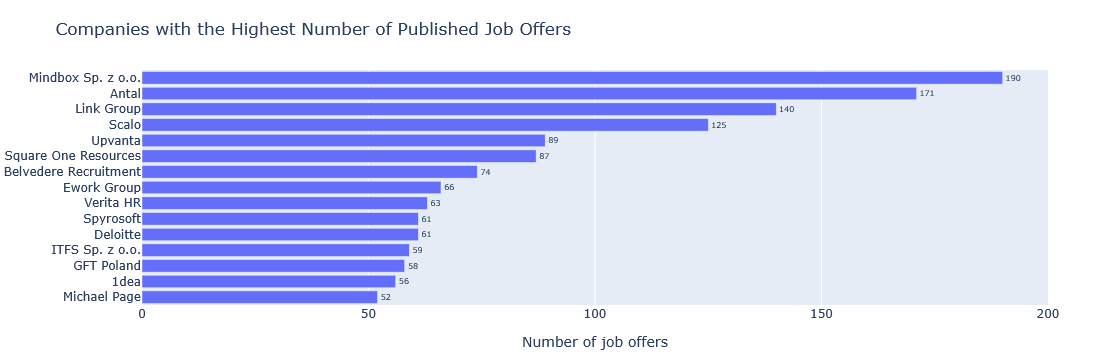

In [60]:
import plotly.express as px

fig = px.bar(
    top_10_companies,
    x="job_offers",
    y="company",
    orientation="h",
    text="job_offers",
    title=(
        "Companies with the Highest Number "
        "of Published Job Offers"
    ),
    labels={
        "job_offers": "Number of job offers",
        "company": "Company",
    },
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    yaxis_title=None,
    showlegend=False,
    margin=dict(
        l=20,
        r=60,
        t=70,
        b=40,
    ),
)

fig.show()

In [61]:
company_offer_counts = (
    df.dropna(subset=["company"])
    .groupby("company")["job_id"]
    .nunique()
    .sort_values(ascending=False)
)

total_companies = company_offer_counts.size
total_offers_with_company = company_offer_counts.sum()

top_10_offers = company_offer_counts.head(10).sum()
top_20_offers = company_offer_counts.head(20).sum()

top_10_share = (
    top_10_offers
    / total_offers_with_company
    * 100
)

top_20_share = (
    top_20_offers
    / total_offers_with_company
    * 100
)

single_offer_companies = (
    company_offer_counts == 1
).sum()

single_offer_company_share = (
    single_offer_companies
    / total_companies
    * 100
)

median_offers_per_company = (
    company_offer_counts.median()
)

In [62]:
market_concentration = pd.DataFrame({
    "metric": [
        "Companies",
        "Offers with identified company",
        "Offers from Top 10 companies",
        "Offers from Top 10 companies (%)",
        "Offers from Top 20 companies",
        "Offers from Top 20 companies (%)",
        "Companies with one offer",
        "Companies with one offer (%)",
        "Median offers per company",
    ],
    "value": [
        total_companies,
        total_offers_with_company,
        top_10_offers,
        round(top_10_share, 1),
        top_20_offers,
        round(top_20_share, 1),
        single_offer_companies,
        round(single_offer_company_share, 1),
        median_offers_per_company,
    ],
})

market_concentration

,metric,value
0,Companies,352.0
1,Offers with identified company,2856.0
2,Offers from Top 10 companies,1066.0
3,Offers from Top 10 companies (%),37.3
4,Offers from Top 20 companies,1591.0
5,Offers from Top 20 companies (%),55.7
6,Companies with one offer,146.0
7,Companies with one offer (%),41.5
8,Median offers per company,2.0


### Key observation

Job-posting activity is strongly concentrated among a relatively small group of organizations. The 10 most active companies account for 37.3% of offers with an identified company, while the Top 20 account for 55.7%.

At the same time, 41.5% of companies published only one offer, and the median company published two offers. This indicates a long-tail distribution: a small number of highly active recruitment, consulting and outsourcing companies generate a substantial share of listings, while most organizations appear only occasionally.

These results describe the concentration of job postings observed on No Fluff Jobs and should not be interpreted as formal market shares of employers.

## Company Size Distribution

This section examines which company-size segments publish the most job offers. Company-size segments are based on the reported lower employee-count boundary.

In [69]:
df.groupby('company_size')['job_id'].count()

company_size
+1000    79
+120      6
+2400    15
+400      1
+6000    42
         ..
800+      1
8000+     8
8500+     4
90+       1
> 150     6
Name: job_id, Length: 68, dtype: int64

In [73]:
df['company_size'].count()

np.int64(2022)

In [85]:
company_size_order = [
    "Small",
    "Medium",
    "Large",
    "Enterprise",
    "Missing",
]

company_size_summary = (
    df["company_size_segment"]
    .value_counts()
    .reindex(
        company_size_order,
        fill_value=0,
    )
    .rename_axis("company_size_segment")
    .reset_index(name="job_offers")
)

company_size_summary["percentage"] = (
    company_size_summary["job_offers"]
    / len(df)
    * 100
).round(1)

company_size_summary

,company_size_segment,job_offers,percentage
0,Small,154,5.4
1,Medium,432,15.1
2,Large,776,27.2
3,Enterprise,660,23.1
4,Missing,834,29.2


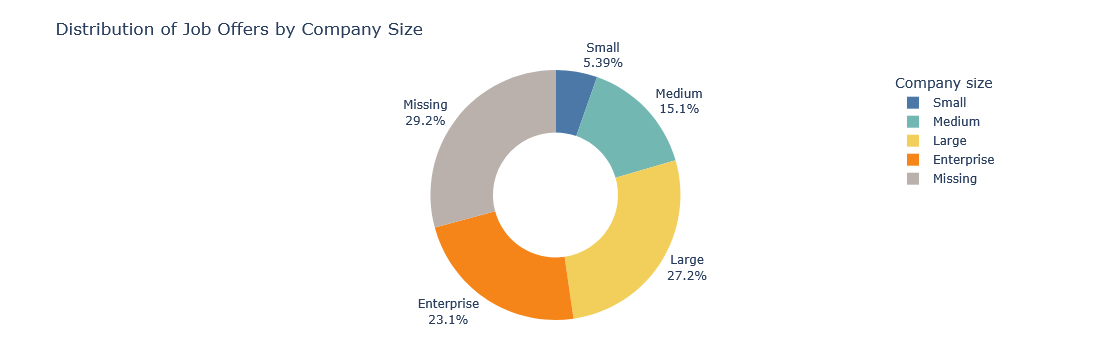

In [87]:
company_size_colors = {
    "Small": "#4C78A8",
    "Medium": "#72B7B2",
    "Large": "#F2CF5B",
    "Enterprise": "#F58518",
    "Missing": "#BAB0AC",
}

fig = px.pie(
    company_size_summary,
    names="company_size_segment",
    values="job_offers",
    hole=0.5,
    title="Distribution of Job Offers by Company Size",
    color="company_size_segment",
    color_discrete_map=company_size_colors,
    category_orders={
        "company_size_segment": company_size_order,
    },
)

fig.update_traces(
    textinfo="percent+label",
    textposition="outside",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Job offers: %{value}<br>"
        "Share: %{percent}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    showlegend=True,
    legend_title_text="Company size",
    margin=dict(
        l=40,
        r=40,
        t=70,
        b=40,
    ),
)

fig.show()